# Hospital Readmission Risk Prediction
## 01. Initial Notebook

This notebook demonstrates a **simple notebook** for predicting 30-day readmission risk for diabetic inpatients.

**Workflow steps:**
1. Load data
2. Prepare features
3. Train model
4. Evaluate on validation set

## Imports
- **pandas**: Data manipulation
- **scikit-learn**: Feature engineering and Logistic Regression
- **seaborn/matplotlib**: Visualization

In [1]:
%pip install numpy pandas seaborn matplotlib scikit-learn
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Feature engineering and Logistic Regression
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## Data Source
The data comes from the [Diabetes 130-US Hospitals](https://archive.ics.uci.edu/dataset/296) dataset (UCI ML Repository, Strack et al., 2014).

- **Target**: Binary — readmitted within 30 days (yes/no)
- **Features**: Demographics, admission context, clinical utilization, medications

In [3]:
from pathlib import Path
# Support both: run from 01-initial-notebook/ or from project root
_candidates = [Path('../data/diabetic_data.csv'), Path('data/diabetic_data.csv')]
DATA_PATH = str(next((p for p in _candidates if p.exists()), _candidates[0]))

# Feature columns for modeling (subset from proposal)
FEATURE_COLS = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_emergency', 'number_inpatient', 'number_outpatient', 'number_diagnoses',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'age', 'gender', 'change', 'diabetesMed'
]
TARGET = 'target'

## Define Data Loading Function

We define a function to load and preprocess the Diabetes 130-US Hospitals data:

- **Target**: Binary — 1 if readmitted within 30 days (`readmitted` in `['30', '<30']`), else 0. Dataset versions vary: some use `'30'`, others use `'<30'`.
- **Missing values**: Fill categorical columns with sensible defaults
- **Sampling**: When `limit` is set, we use **random sampling** (not `nrows`) so both classes appear in the sample. The raw CSV may be ordered such that positive cases cluster later; taking only the first N rows can yield a single class and cause LogisticRegression to fail.
- **Split**: Use stratified train-validation split to preserve class balance (11.2% positive)

In [4]:
def read_data(path: str, limit: int = None):
    df = pd.read_csv(path)
    # Binary target: 1 if readmitted within 30 days
    # Values: 'NO', '<30' (positive), '>30' — some datasets use '30' instead of '<30'
    readm = df['readmitted'].astype(str).str.strip()
    df['target'] = readm.isin(['30', '<30']).astype(int)
    # Fill missing categoricals
    df['age'] = df['age'].fillna('[50-60)')
    df['gender'] = df['gender'].fillna('Unknown')
    df['change'] = df['change'].fillna('No')
    df['diabetesMed'] = df['diabetesMed'].fillna('No')
    # Ensure numeric cols
    for col in ['num_lab_procedures', 'num_procedures', 'num_medications',
                'number_emergency', 'number_inpatient', 'number_outpatient', 'number_diagnoses']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    if limit is not None:
        df = df.sample(n=min(limit, len(df)), random_state=42)
    return df

## Load Data and Split Train/Validation
We load the dataset and perform a stratified 80/20 train-validation split to preserve class balance.

In [5]:
df = read_data(DATA_PATH, limit=50_000)
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df[TARGET])

print('Train shape:', df_train.shape)
print('Val shape:  ', df_val.shape)
print(f'Target positive rate (train): {df_train[TARGET].mean():.2%}')
df_train.head()

Train shape: (40000, 51)
Val shape:   (10000, 51)
Target positive rate (train): 11.18%


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,target
80377,247809876,115003134,Caucasian,Female,[60-70),?,1,3,7,3,...,Down,No,No,No,No,No,Ch,Yes,NO,0
29762,96918234,77972157,Caucasian,Male,[50-60),?,1,1,7,3,...,No,No,No,No,No,No,No,No,NO,0
59728,167745984,99532287,AfricanAmerican,Female,[40-50),?,2,1,1,2,...,No,No,No,No,No,No,No,No,<30,1
32431,103385832,80607951,Caucasian,Female,[30-40),?,2,1,7,2,...,Steady,No,No,No,No,No,No,Yes,<30,1
82759,258048894,84583692,Caucasian,Male,[50-60),?,1,2,7,4,...,No,No,No,No,No,No,No,No,>30,0


## Prepare Features (One-Hot Encoding)

Categorical columns (`age`, `gender`, `change`, `diabetesMed`) are one-hot encoded. Numeric columns are passed through. We use scikit-learn's `DictVectorizer` to transform the feature dicts.

In [6]:
# Convert categoricals to string for DictVectorizer
df_train[['age', 'gender', 'change', 'diabetesMed']] = df_train[['age', 'gender', 'change', 'diabetesMed']].astype(str)
df_val[['age', 'gender', 'change', 'diabetesMed']] = df_val[['age', 'gender', 'change', 'diabetesMed']].astype(str)

# Build feature dicts
train_dicts = df_train[FEATURE_COLS].to_dict(orient='records')
val_dicts = df_val[FEATURE_COLS].to_dict(orient='records')

# Fit on train, transform both
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

y_train = df_train[TARGET].values
y_val = df_val[TARGET].values

print('Feature matrix (train):', X_train.shape)
print('Number of features:    ', len(dv.feature_names_))

Feature matrix (train): (40000, 28)
Number of features:     28


In [7]:
# Sanity check: ensure both classes exist (required for LogisticRegression)
n_classes = len(np.unique(y_train))
if n_classes < 2:
    print(f"ERROR: y_train has only {n_classes} class(es). LogisticRegression needs at least 2.")
    print(f"  - Check DATA_PATH: {DATA_PATH} (relative to notebook dir: 01-initial-notebook/)")
    print(f"  - readmitted unique values in train: {df_train['readmitted'].astype(str).unique()[:5]}")
    raise ValueError("Training data must contain both classes (0 and 1). Check data path and readmitted column.")
print(f"y_train classes: {np.unique(y_train)} (OK)")

y_train classes: [0 1] (OK)


## Train Logistic Regression (Baseline)
Fit a **Logistic Regression** model as the baseline (per proposal). Compute **accuracy** and **PR-AUC** on the training set.

In [8]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_proba_train = lr.predict_proba(X_train)[:, 1]

acc_train = accuracy_score(y_train, y_pred_train)
pr_auc_train = average_precision_score(y_train, y_proba_train)

print(f'Train Accuracy: {acc_train:.3f}')
print(f'Train PR-AUC:  {pr_auc_train:.3f}')

Train Accuracy: 0.888
Train PR-AUC:  0.194


### Quick Visual Check
Plot histograms of predicted probabilities for positive vs negative class to visually compare distributions.

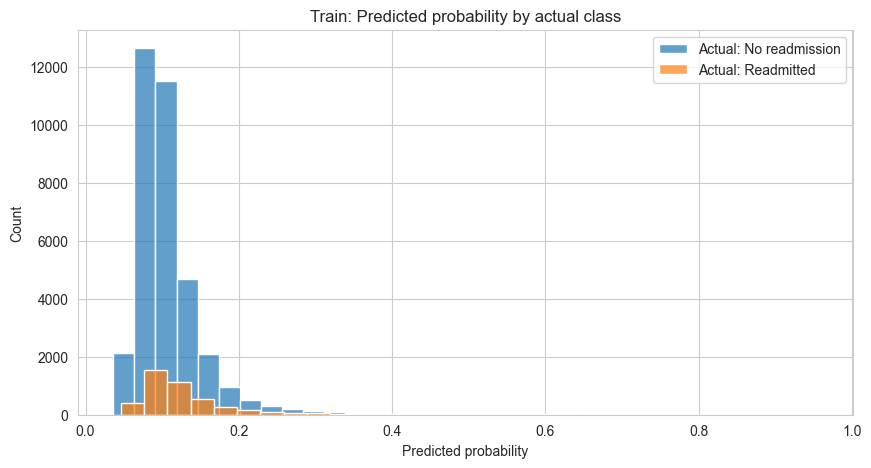

In [9]:
sns.histplot(y_proba_train[y_train == 0], label='Actual: No readmission', stat='count', bins=30, alpha=0.7)
sns.histplot(y_proba_train[y_train == 1], label='Actual: Readmitted', stat='count', bins=30, alpha=0.7)
plt.legend()
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Train: Predicted probability by actual class')
plt.show()

## Validate the Model
Use the **same vectorizer** on the validation set (never `fit` on validation), predict, and report metrics.

In [10]:
y_pred_val = lr.predict(X_val)
y_proba_val = lr.predict_proba(X_val)[:, 1]

acc_val = accuracy_score(y_val, y_pred_val)
pr_auc_val = average_precision_score(y_val, y_proba_val)
roc_auc_val = roc_auc_score(y_val, y_proba_val)

print(f'Val Accuracy: {acc_val:.3f}')
print(f'Val PR-AUC:   {pr_auc_val:.3f}')
print(f'Val ROC-AUC:  {roc_auc_val:.3f}')

Val Accuracy: 0.888
Val PR-AUC:   0.199
Val ROC-AUC:  0.649
